# DQN+BC Evaluation

In [1]:
import sys
import os
import torch
import pandas as pd

if 'google.colab' in sys.modules:
  from google.colab import drive
  drive.mount( "/content/drive")
  if os.path.isdir('drive/MyDrive/Projects/Offline_RL_BSc_Thesis/notebooks/DQN/DQN_BC'):
    os.chdir('drive/MyDrive/Projects/Offline_RL_BSc_Thesis/notebooks/DQN/DQN_BC')


project_root = os.path.abspath(os.path.join(os.path.dirname("__file__"), "../../../../"))
if project_root not in sys.path:
    sys.path.append(project_root)

torch_device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

## Test Evaluation

In [2]:
from src.utils.evaluation import print_model_eval_results, evaluate_model_test_dataset
from src.utils.plotting import plot_confusion_matrix_heatmap

C:\Users\Miro\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Replay Buffer

Model Evaluation results of BC Replay Buffer
accuracy: 0.21675668787311422
balanced_accuracy: 0.2731337636222591
precision_macro: 0.3099603555766746
recall_macro: 0.2731337636222591
f1_macro: 0.189264358165677
precision_weighted: 0.479807261908449
recall_weighted: 0.21675668787311422
f1_weighted: 0.2438538642441124
precision_per_class: [0.40289855 0.09835173 0.64290695 0.09568419]
recall_per_class: [0.06274451 0.36671655 0.22788587 0.43518813]
f1_per_class: [0.10857961 0.15510499 0.3364966  0.15687623]
confusion_matrix: [[ 1668  9687  3365 11864]
 [  415  3431  2039  3471]
 [ 1511 18749 12907 23471]
 [  546  3018  1765  4106]]
classification_report:
  0: {'precision': 0.4028985507246377, 'recall': 0.06274450797472164, 'f1-score': 0.10857961202968364, 'support': 26584.0}
  1: {'precision': 0.09835172710333955, 'recall': 0.3667165455322787, 'f1-score': 0.15510499310594245, 'support': 9356.0}
  2: {'precision': 0.6429069535764096, 'recall': 0.22788587167625976, 'f1-score': 0.3364965977526

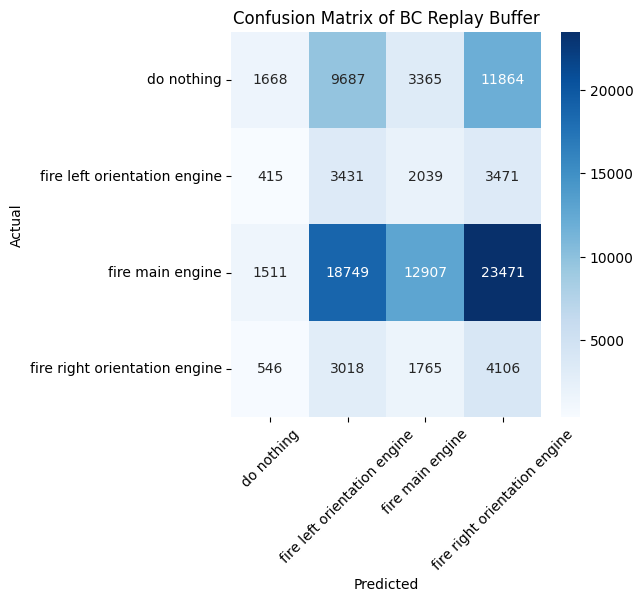

In [3]:
rb_norm_name = 'standard'

rb_test_df = pd.read_parquet('../../../data/replay_buffer_episodes/rb_test.parquet').drop(columns=['done', 'episode', 'reward'])
rb_normalization_technique = torch.jit.load(f'../../../models/BC/replay_buffer/normalization/{rb_norm_name}_normalization.pt')
#rb_normalization_technique = None
rb_model = torch.jit.load(f'../../../models/DQN/replay_buffer/DQN_BC_{rb_norm_name}.pt')

rb_classificiation_repport_dict, rb_confusion_matrix = evaluate_model_test_dataset(model=rb_model,
                            device=torch_device,
                            test_df=rb_test_df,
                            norm_technique_script=rb_normalization_technique,
                            selected_features=['X', 'Y', 'lv_X', 'lv_Y', 'reward', 'angle', 'angular_velocity', 'leg_1', 'leg_2'],
                            apply_softmax=False)

rb_confusion_matrix_fig = plot_confusion_matrix_heatmap(confusion_matrix=rb_confusion_matrix,
                                                        model_name='DQN+BC Replay Buffer',
                                                        f_size=(5,5))

print_model_eval_results(rb_classificiation_repport_dict,
                         model_name='DQN+BC Replay Buffer')

### Final Policy

Model Evaluation results of BC Final Policy
accuracy: 0.13075952561191018
balanced_accuracy: 0.2011082823857573
precision_macro: 0.31519051561656514
recall_macro: 0.2011082823857573
f1_macro: 0.13584151576054238
precision_weighted: 0.5418957965677127
recall_weighted: 0.13075952561191018
f1_weighted: 0.16083536363450798
precision_per_class: [0.50160114 0.02645072 0.66977226 0.06293794]
recall_per_class: [0.21750177 0.26259435 0.04786211 0.2764749 ]
f1_per_class: [0.30343122 0.0480604  0.08933996 0.10253448]
confusion_matrix: [[ 7362 18314   543  7629]
 [ 1747  1496   378  2076]
 [ 4553 34169  2588 12762]
 [ 1015  2579   355  1509]]
classification_report:
  0: {'precision': 0.5016011446480888, 'recall': 0.2175017726305838, 'f1-score': 0.30343122102009273, 'support': 33848.0}
  1: {'precision': 0.026450723151455142, 'recall': 0.26259434790240477, 'f1-score': 0.0480603967552807, 'support': 5697.0}
  2: {'precision': 0.6697722567287785, 'recall': 0.047862109779553186, 'f1-score': 0.08933996

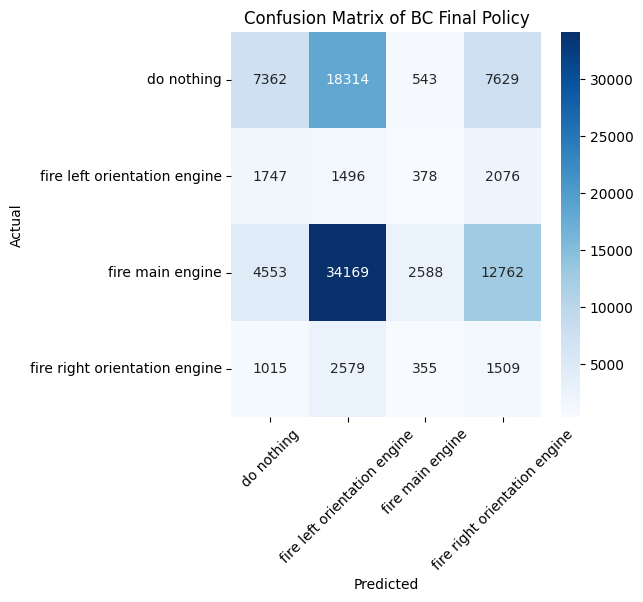

In [5]:
fp_norm_name = 'max_abs'

fp_test_df = pd.read_parquet('../../../data/final_policy_episodes/fp_test.parquet').drop(columns=['done', 'episode', 'reward'])
fp_normalization_technique = torch.jit.load(f'../../../models/BC/final_policy/normalization/{fp_norm_name}_normalization.pt')
#fp_normalization_technique = None
fp_model = torch.jit.load(f'../../../models/DQN/final_policy/DQN_BC_{fp_norm_name}.pt')


fp_classificiation_repport_dict, fp_confusion_matrix = evaluate_model_test_dataset(model=fp_model,
                            device=torch_device,
                            test_df=fp_test_df,
                            norm_technique_script=fp_normalization_technique,
                            selected_features=['X', 'Y', 'lv_X', 'lv_Y', 'reward', 'angle', 'angular_velocity', 'leg_1', 'leg_2'],
                            apply_softmax=False)

fp_confusion_matrix_fig = plot_confusion_matrix_heatmap(confusion_matrix=fp_confusion_matrix,
                                                        model_name='DQN+BC Final Policy',
                                                        f_size=(5,5))

print_model_eval_results(fp_classificiation_repport_dict,
                         model_name='DQN+BC Final Policy')

## Evaluation in the Live Environment for 1000 episodes

In [6]:
import yaml
import warnings

from src.utils.live_env_testing import DQN_BC_evaluate_model_in_live_env

warnings.filterwarnings("ignore")
with open('../../../config/DQN/DQN_BC/dqn_bc_live_env_elavuation_config.yaml', 'r') as f:
    dqn_bc_live_env_config_config = yaml.safe_load(f)

### Replay Buffer

In [7]:
rb_rewards = DQN_BC_evaluate_model_in_live_env(
    env_test_params=dqn_bc_live_env_config_config,
    model_name='replay_buffer',
    norm_technique=rb_normalization_technique,
    model = rb_model
)

100%|██████████| 1000/1000 [02:52<00:00,  5.79it/s]


### Final Policy

In [8]:
fp_rewards = DQN_BC_evaluate_model_in_live_env(
    env_test_params=dqn_bc_live_env_config_config,
    norm_technique=fp_normalization_technique,
    model_name='final_policy',
    model = fp_model
)

100%|██████████| 1000/1000 [00:52<00:00, 19.17it/s]


### Accumulated rewards distribution comparison

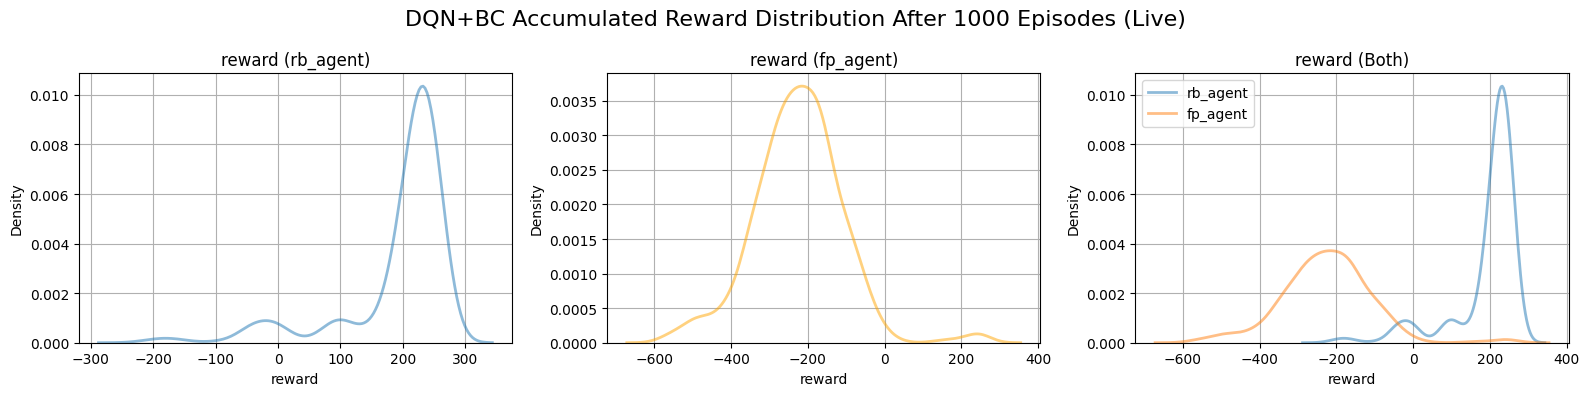

In [9]:
from src.utils.plotting import plot_univariate_analysis


rb_rewards_df = pd.DataFrame(rb_rewards, columns=['reward'])
fp_rewards_df = pd.DataFrame(fp_rewards, columns=['reward'])

rb_fp_combined_fig = plot_univariate_analysis(
        df1_name = 'rb_agent',
        df2_name = 'fp_agent',
        df1=rb_rewards_df,
        df2=fp_rewards_df,
        num_columns=3,
        custom_title='DQN+BC Accumulated Reward Distribution After 1000 Episodes (Live)',
        kde_kwargs={'linewidth': 2, 'alpha': 0.5},
        f_size=(16,4))
rb_fp_combined_fig.savefig('../../../plots/DQN_BC_liven_env_1000_ep_eval_rb_fp.jpg')